<a href="https://colab.research.google.com/github/slackoly/ES2245/blob/main/ES2245_lab10_sedlacko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 10: Multivariate Analysis, Clustering, and Geostatistics
**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

## Overview
This lab will take approximately one hour to complete. We will explore techniques used in the Earth and Environmental Sciences to analyze complex, multi-dimensional datasets and spatial data.

The lab is divided into three parts:
1. **Principal Component Analysis (PCA)**
2. **Cluster Analysis**
3. **Geostatistics and Variograms**

For each section, read the introductory text, execute the provided code, complete the blocks labeled `# YOUR CODE HERE`, and answer the overview questions at the bottom of each section.

---
## Part 1: Principal Component Analysis (PCA)

In earth science, we often measure many variables for a single sample, such as the concentrations of copper, silver, lead, and zinc across a large ore body. Visualizing and comparing data in four or more dimensions is inherently difficult. PCA is an **R-mode analysis** because its primary focus is on the variables rather than the individual samples. It identifies correlations among redundant variables and mathematically re-expresses them into a smaller number of new, composite variables called **Principal Components**.

### The PCA Process:
1. **Standardization:** PCA is sensitive to variables with different scales, so we standardize the data so that each feature has a mean of 0 and a variance of 1.
2. **Covariance Matrix Computation:** Identifies how variables relate to each other and checks for redundancy.
3. **Eigen-decomposition:** Calculates the eigenvectors (directions of new axes) and eigenvalues (amount of variance carried by each eigenvector).
4. **Recasting the Data:** Reorients the original data from the old axes to the new principal components.

Original Dataset Head:


,Copper,Silver,Lead,Gold,Zinc
Site_1,24.981605,5.720457,50.592645,21.656525,16.101912
Site_2,48.028572,38.946845,26.974693,6.797820,34.758846
Site_3,39.279758,34.135492,34.607232,3.211754,11.719426
Site_4,33.946339,12.431869,38.318092,33.262108,55.466020
Site_5,16.240746,11.363874,42.803499,33.831489,22.938999


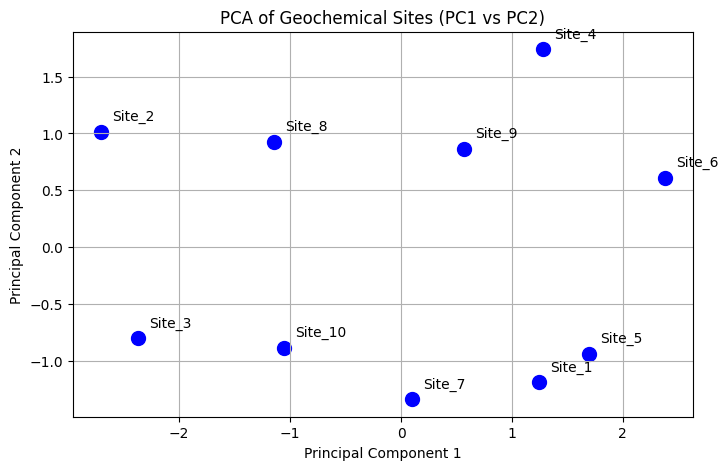

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Mock Geochemical Data (Sites A-J, Metals: Cu, Ag, Pb, Au, Zn)
np.random.seed(42)
data = {
    'Copper': np.random.uniform(10, 50, 10),
    'Silver': np.random.uniform(5, 40, 10),
    'Lead': np.random.uniform(20, 70, 10),
    'Gold': np.random.uniform(1, 35, 10),
    'Zinc': np.random.uniform(10, 60, 10)
}
df = pd.DataFrame(data, index=['Site_'+str(i) for i in range(1, 11)])
print("Original Dataset Head:")
display(df.head())

# 1. Standardize the data
scaler = StandardScaler()
# YOUR CODE HERE: Fit and transform the dataframe 'df' using the scaler

scaled_data = scaler.fit_transform(df)

# 2. Perform PCA
# YOUR CODE HERE: Initialize a PCA object to keep 2 components (n_components=2),
# then fit_transform the scaled_data

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)


# Let's plot the first two principal components!
plt.figure(figsize=(8, 5))
# UNCOMMENT the lines below once you have created pca_features successfully
plt.scatter(pca_features[:, 0], pca_features[:, 1], c='blue', s=100)
for i, site in enumerate(df.index):
     plt.annotate(site, (pca_features[i, 0]+0.1, pca_features[i, 1]+0.1))
plt.title('PCA of Geochemical Sites (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Concept Questions: Part 1
**Question 1.1:** Why is the standardization step crucial before calculating the covariance matrix in PCA? *(Hint: Think about what would happen if age was measured in years and income in thousands)*.

**Your Answer:** *Standardization ensures that the units for variables do not influence their weight, making each variable comparable.*

**Question 1.2:** While PCA is powerful for reducing dimensionality and visualizing patterns, it has trade-offs. Explain the primary drawback of PCA regarding "Interpretability."

**Your Answer:** *PCA creates complicated, mathematically amalgamated components that can be difficult to communicate to target audiences.*

---
## Part 2: Cluster Analysis

While PCA focuses on simplifying variables, **Cluster Analysis** is a **Q-mode analysis** used to classify sampling units into discrete groups or clusters. It serves as a quantitative way to assign units to groups such that units within a particular cluster are more similar to each other than they are to units in different clusters.

Hierarchical clustering begins with a **dissimilarity matrix** (such as Euclidean distance) to find the two sites with the lowest dissimilarity and joins them into the first cluster. The process is repeated iteratively. The primary output is a **dendrogram**, a tree-like diagram that illustrates the levels of similarity at which various units and clusters were joined.

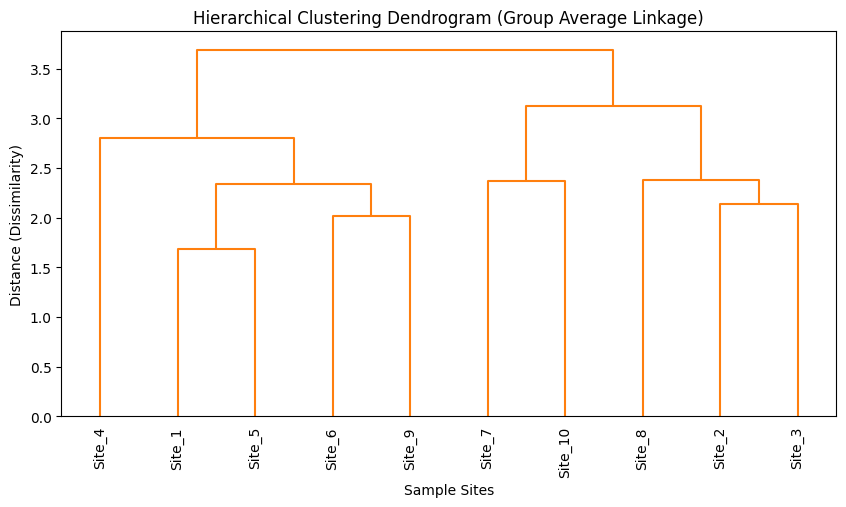

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Calculate the dissimilarity matrix (Euclidean distances)
# We will use the scaled_data from Part 1
# UNCOMMENT the line below once scaled_data is defined in Part 1
distance_matrix = pdist(scaled_data, metric='euclidean')

# YOUR CODE HERE: Create the linkage matrix 'Z' using the scipy 'linkage' function.
# Pass in the distance_matrix and use the 'average' linkage method (Group average linkage).

Z = linkage(distance_matrix, method='average')

plt.figure(figsize=(10, 5))
plt.title('Hierarchical Clustering Dendrogram (Group Average Linkage)')
plt.xlabel('Sample Sites')
plt.ylabel('Distance (Dissimilarity)')

# YOUR CODE HERE: Plot the dendrogram using the linkage matrix 'Z' and set labels=df.index

dendrogram(Z, labels=df.index, leaf_rotation=90, leaf_font_size=10, color_threshold=15)
plt.show()


### Concept Questions: Part 2
**Question 2.1:** A dendrogram shows "solutions" at different levels of internal dissimilarity. According to your plot, at roughly what dissimilarity distance do all the sites merge into a "single-category solution"?

**Your Answer:** *Approximately 3.5*

**Question 2.2:** The lecture provides a critical caution about the "groups" formed by cluster analysis. Because dissimilarity is a continuous variable, what does the lecture warn us about interpreting these groupings as "true" natural nominal states (like a specific rock type)?

**Your Answer:** *These clusters might not properly correspond to the to true naural categories, as the groups are just where the line was drawn on the dendrogram.*

---
## Part 3: Geostatistics and Variograms

Traditional statistics assume data points are independent of one another, but **Geostatistics** operates on the premise that data points collected close to each other are more similar than those collected farther apart. This foundational concept is known as **Tobler’s First Law of Geography**.

Before predicting unknown spatial values, geostatisticians use an Exploratory Spatial Data Analysis (ESDA) tool called a **Semivariogram** (or variogram). It plots the variance between data points against the geographical distance (lag) separating them, allowing scientists to fit a mathematical model to the data's spatial continuity.

<>:40: SyntaxWarning: invalid escape sequence '\g'
<>:40: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_6640/162994871.py:40: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Semivariance ($\gamma$)')


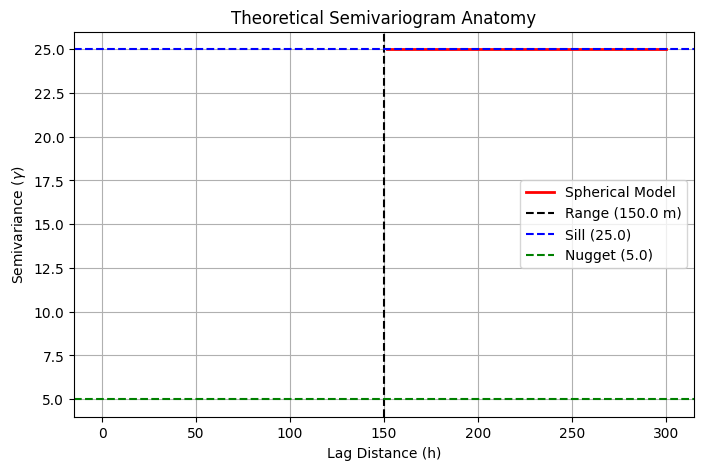

In [10]:
# Let's mathematically model a theoretical variogram curve (Spherical model)
# to visualize its core anatomical components.

def spherical_variogram(h, nugget, sill, range_val):
    """
    Calculates the theoretical semivariance using a Spherical model.
    h: lag distance
    """
    # YOUR CODE HERE:
    # 1. If h == 0, return the nugget.
    # 2. If h >= range_val, return the sill.
    # 3. Otherwise, return: nugget + (sill - nugget) * (1.5 * (h / range_val) - 0.5 * (h / range_val)**3)

    if h == 0:
        return nugget
    elif h >= range_val:
        return sill
    else: nugget + (sill - nugget) * (1.5 * (h / range_val) - 0.5 * (h / range_val)**3)

# Generate lag distances
h_lags = np.linspace(0, 300, 100)

# Set spatial parameters
nugget_val = 5.0
sill_val = 25.0
range_limit = 150.0

# UNCOMMENT the lines below once you have completed the function above:
gamma_vals = [spherical_variogram(h, nugget_val, sill_val, range_limit) for h in h_lags]

plt.figure(figsize=(8, 5))
# UNCOMMENT the lines below to plot
plt.plot(h_lags, gamma_vals, color='red', lw=2, label='Spherical Model')
plt.axvline(x=range_limit, color='k', linestyle='--', label=f'Range ({range_limit} m)')
plt.axhline(y=sill_val, color='b', linestyle='--', label=f'Sill ({sill_val})')
plt.axhline(y=nugget_val, color='g', linestyle='--', label=f'Nugget ({nugget_val})')

plt.title('Theoretical Semivariogram Anatomy')
plt.xlabel('Lag Distance (h)')
plt.ylabel('Semivariance ($\gamma$)')
plt.legend()
plt.grid(True)
plt.show()

### Concept Questions: Part 3
**Question 3.1:** Define the **Nugget**, **Sill**, and **Range** of a variogram. If two sample points are separated by a distance *greater* than the range, what does that indicate about their spatial relationship?

**Your Answer:** *The nugget is the y-intercept (ideally zero), the sill is the plateau (where the samples are no longer correlated), and the range is the distance on the x-axis where the variogram reaches the sill. Two points separated by a distance greater than the range are spatially independent.*

**Question 3.2:** **Kriging** uses the theoretical variogram model you explored above to predict values at unsampled locations. It is known as the Best Linear Unbiased Estimator (BLUE). What does it mean for Kriging to be "unbiased", and how does Kriging handle weights if multiple sample points are tightly clustered together?

**Your Answer:** *Kriging is unbiased, as the estimated values equal the true values and the average error is zero. When multiple sample points are tightly clustered together, Kriging will recognize the redundancy and reduce their individual weights, allowing for fair representation of other isolated points.*

---
## Part 4: Applied Geostatistics: GPS Velocity Fields

In geodesy and geophysics, we use networks of GPS (GNSS) stations to measure the tectonic movement of the Earth's crust over time. In the Western United States, the Pacific Plate is sliding northwest relative to the North American Plate, creating a complex deformation zone (including the San Andreas Fault).

However, we only have GPS stations at discrete locations. To understand the continuous strain and movement of the crust, we must interpolate these data points into a continuous **velocity field**. In this exercise, we will use **Ordinary Kriging** to interpolate a realistic subset of GPS velocities from the Western US.

*Note: You may need to install the `pykrige` library by running `!pip install pykrige` in a cell before executing the code below.*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.9 MB/s eta 0:00:00


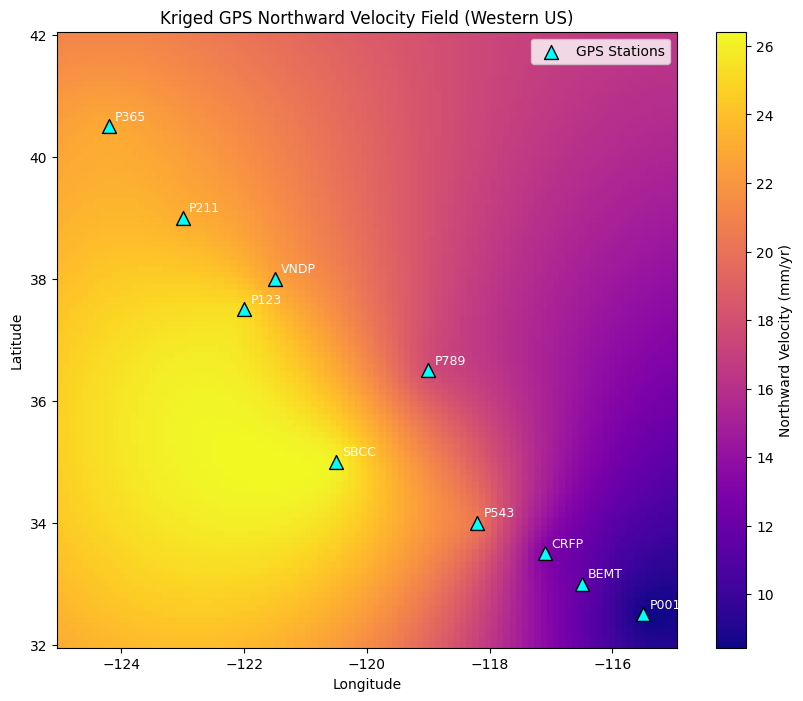

In [11]:
!pip install pykrige
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

# Subset of realistic GPS station velocities for the Western US (California region)
# Velocities are in mm/year.
gps_data = {
    'Station': ['P365', 'P123', 'SBCC', 'P543', 'BEMT', 'P211', 'VNDP', 'P789', 'CRFP', 'P001'],
    'Lon': [-124.2, -122.0, -120.5, -118.2, -116.5, -123.0, -121.5, -119.0, -117.1, -115.5],
    'Lat': [40.5, 37.5, 35.0, 34.0, 33.0, 39.0, 38.0, 36.5, 33.5, 32.5],
    'V_North': [25.1, 30.5, 32.1, 28.4, 15.2, 22.0, 18.5, 12.1, 5.5, 2.1],
    'V_East': [-15.2, -22.1, -25.0, -20.5, -10.1, -12.5, -8.0, -5.2, -2.1, -1.0]
}
df_gps = pd.DataFrame(gps_data)

# Create a spatial grid for interpolation
grid_lon = np.linspace(-125, -115, 100)
grid_lat = np.linspace(32, 42, 100)

# YOUR CODE HERE: Initialize Ordinary Kriging for the Northward Velocity (V_North)
# Pass in the Longitude, Latitude, and V_North from the dataframe.
# Use the 'spherical' variogram model and set nlags=6.

OK_north = OrdinaryKriging(df_gps['Lon'], df_gps['Lat'], df_gps['V_North'], variogram_model='spherical', nlags=6)

# YOUR CODE HERE: Execute the Kriging interpolation over the defined grid (grid_lon, grid_lat)
# Hint: Use the 'grid' style in the execute method.
z_north, ss_north = OK_north.execute('grid', grid_lon, grid_lat)

# Plotting the interpolated velocity field
plt.figure(figsize=(10, 8))
# UNCOMMENT the lines below once you have completed the Kriging steps above
c = plt.pcolormesh(grid_lon, grid_lat, z_north, shading='auto', cmap='plasma')
plt.colorbar(c, label='Northward Velocity (mm/yr)')

plt.scatter(df_gps['Lon'], df_gps['Lat'], c='cyan', edgecolors='k', marker='^', s=100, label='GPS Stations')
for i, txt in enumerate(df_gps['Station']):
    plt.annotate(txt, (df_gps['Lon'][i]+0.1, df_gps['Lat'][i]+0.1), color='white', fontsize=9)

plt.title('Kriged GPS Northward Velocity Field (Western US)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

### Concept Questions: Part 4
**Question 4.1:** Why is Kriging preferred over simpler interpolation methods (like Inverse Distance Weighting or Nearest Neighbor) when mapping a tectonic velocity field?

**Your Answer:** *Kriging doesn't just estimate unknown values; it also measures uncertainty for theose estimates.*

**Question 4.2:** Looking at the interpolated field, what does a steep gradient (a rapid change in color/velocity over a short distance) represent in a real geological setting?

**Your Answer:** *A steep gradient represents a physical change in the field, such as a fault or boundary.*

---
## Part 5: Applied PCA: Earthquake Fault Plane Identification

Earthquakes do not occur randomly; they cluster along fault planes. When a large earthquake occurs, it is often followed by hundreds of aftershocks. Seismologists record the 3D coordinates (Longitude, Latitude, Depth) of these aftershocks.

By applying **Principal Component Analysis (PCA)** to the 3D spatial coordinates of an earthquake swarm, we can objectively determine the orientation of the hidden fault plane deep underground.

* **PC1** will find the direction of maximum spread (the primary length of the fault).
* **PC2** will find the secondary spread (the down-dip width of the fault).
* **PC3** represents the variance perpendicular to the fault plane. Therefore, **PC3 acts as the Normal Vector** to the plane. Using this normal vector, we can use trigonometry to explicitly calculate the geological **Strike** and **Dip** of the fault!

*Note: Because we are dealing with true 3D spatial geometry (where X, Y, and Z are all in kilometers), we will only mean-center our data. We will NOT standardize the variance, as changing the scale of the axes would warp the physical angles of the fault plane.*

Explained Variance Ratio by Component:
PC1: 0.5450 (54.5%)
PC2: 0.4536 (45.4%)
PC3: 0.0014 (0.1%)

--- Explicit Fault Orientation ---
Calculated Strike: 269.6°
Calculated Dip:    50.5°
----------------------------------


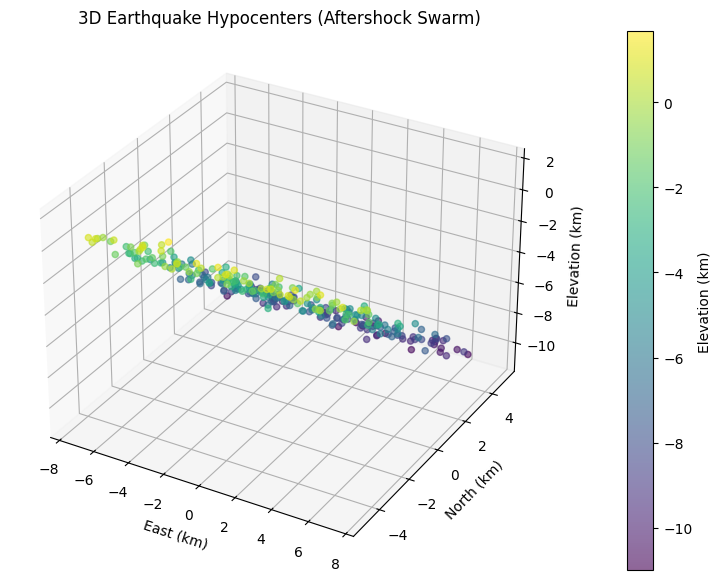

In [12]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate realistic synthetic earthquake hypocenter data along a dipping fault plane
np.random.seed(10)
# 'X' is East/West, 'Y' is North/South, 'Z' is Elevation (Negative = Depth)
strike_dist = np.random.uniform(-7.5, 7.5, 300)
dip_dist = np.random.uniform(-5, 5, 300)

# Fault dips towards the North; elevation (z) drops as y increases, plus some scatter
elevation = -1.2 * dip_dist + np.random.normal(0, 0.4, 300) - 5

df_eq = pd.DataFrame({'X_km': strike_dist, 'Y_km': dip_dist, 'Z_km': elevation})

# YOUR CODE HERE: Mean-center the data
# (DO NOT scale variance to preserve spatial geometry, just subtract the mean of the dataframe)
centered_eq = df_eq - df_eq.mean()

# YOUR CODE HERE: Apply PCA to the 3D spatial data (set n_components=3)
pca_eq = PCA(n_components=3)

# ... fit the PCA to your centered data ...
pca_features_eq = pca_eq.fit_transform(centered_eq)

# UNCOMMENT the lines below once you have fitted your PCA model
print("Explained Variance Ratio by Component:")
for i, var in enumerate(pca_eq.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.1f}%)")

# =====================================================================
# Calculating Strike and Dip from the Normal Vector (PC3)
# =====================================================================

# YOUR CODE HERE: Extract the 3rd principal component (the normal vector to the fault plane)
# Hint: Look at the `components_` attribute of your fitted PCA object. Remember Python uses 0-based indexing.
nx, ny, nz = pca_eq.components_[2]

# Ensure normal vector points generally upwards for standard dip calculation
# UNCOMMENT below once nx, ny, nz are defined
if nz < 0:
    nx, ny, nz = -nx, -ny, -nz

# YOUR CODE HERE: Calculate the DIP angle (in degrees)
# Hint: Since PCA components are unit vectors, np.arccos(nz) gives the dip angle in radians.
# Convert it to degrees using np.degrees().
dip_deg = np.degrees(np.arccos(nz))

# STRIKE: Derived from the dip direction (horizontal projection of the normal vector)
# UNCOMMENT below once nx and ny are defined to calculate strike
dip_direction_deg = (np.degrees(np.arctan2(nx, ny)) + 360) % 360
strike_deg = (dip_direction_deg - 90) % 360

# UNCOMMENT to print explicit orientations
print(f"\n--- Explicit Fault Orientation ---")
print(f"Calculated Strike: {strike_deg:.1f}°")
print(f"Calculated Dip:    {dip_deg:.1f}°")
print(f"----------------------------------")

# Plotting the 3D earthquake swarm
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_eq['X_km'], df_eq['Y_km'], df_eq['Z_km'], c=df_eq['Z_km'], cmap='viridis', alpha=0.6)

ax.set_title('3D Earthquake Hypocenters (Aftershock Swarm)')
ax.set_xlabel('East (km)')
ax.set_ylabel('North (km)')
ax.set_zlabel('Elevation (km)')
plt.colorbar(sc, label='Elevation (km)', pad=0.1)
plt.show()

### Concept Questions: Part 5
**Question 5.1:** Based on the "Explained Variance Ratio" printed by your code, roughly what percentage of the variance is captured by the first two principal components combined? What geometric shape do PC1 and PC2 define together in this context?

**Your Answer:** *The first two principal components capture 99.9% of variance, defining a 2D plane.*

**Question 5.2:** PC3 represents the *least* amount of variance in the dataset. In the physical context of mapping a fault zone using earthquake hypocenters, what does the variance along PC3 actually measure?

**Your Answer:** *PC3 measures the spread of seismic activity and the uncertainty of location.*
